Epoch 100, Loss = 0.590231
Epoch 200, Loss = 0.505468
Epoch 300, Loss = 0.492014
Epoch 400, Loss = 0.487049
Epoch 500, Loss = 0.483314


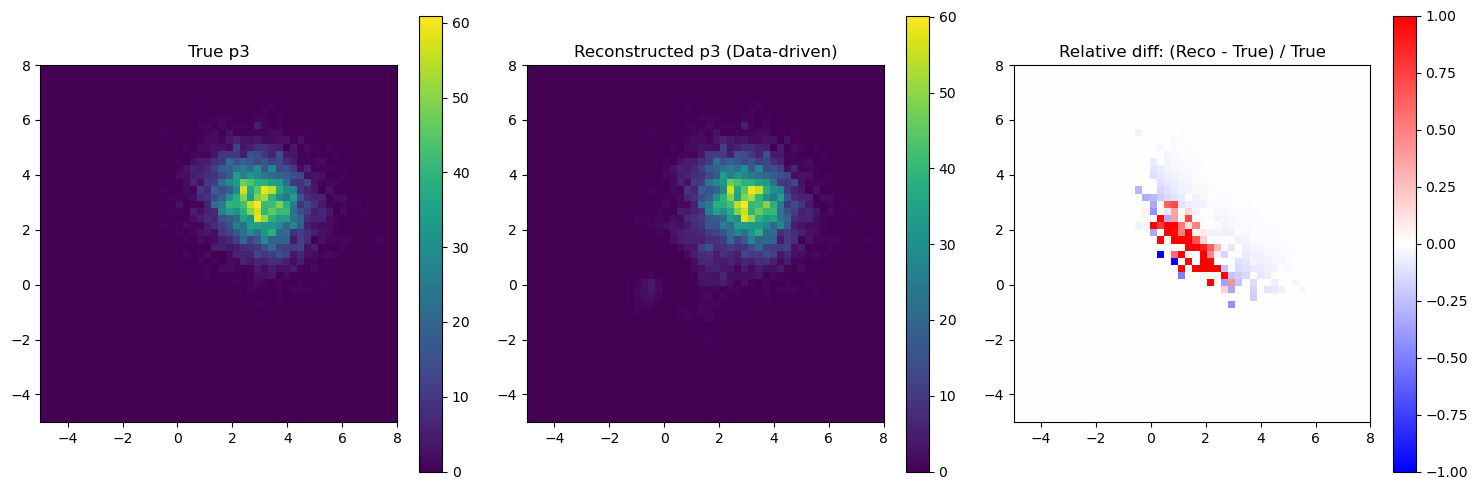

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------
# 1. Generate p2 and p3 samples
# -----------------------
N2 = 5000
N3 = 5000

mean_p2 = [0, 0]
cov_p2 = [[1, 0.3],
          [0.3, 1]]
p2_samples = np.random.multivariate_normal(mean_p2, cov_p2, N2)

mean_p3 = [3, 3]
cov_p3 = [[1, -0.2],
          [-0.2, 1]]
p3_samples = np.random.multivariate_normal(mean_p3, cov_p3, N3)

p1_samples = np.vstack([p2_samples, p3_samples])

# -----------------------
# 2. Prepare training data
# -----------------------
# Label p2 as class 1, p1 as class 0
X_train = np.vstack([p2_samples, p1_samples])
y_train = np.hstack([np.ones(len(p2_samples)), np.zeros(len(p1_samples))])

X_t = torch.tensor(X_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# -----------------------
# 3. Define NN classifier
# -----------------------
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

# Training loop
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = model(X_t)
    loss = loss_fn(y_pred, y_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.6f}")

# -----------------------
# 4. Predict r(x) = p2/p1
# -----------------------
# Make a histogram for p1
bins = 50
hist_range = [[-5, 8], [-5, 8]]
H_p1, xedges, yedges = np.histogram2d(p1_samples[:,0], p1_samples[:,1], bins=bins, range=hist_range)

# Grid for bin centers
xcenters = 0.5*(xedges[:-1] + xedges[1:])
ycenters = 0.5*(yedges[:-1] + yedges[1:])
xx, yy = np.meshgrid(xcenters, ycenters)
grid_points = np.vstack([xx.ravel(), yy.ravel()]).T

# Classifier outputs: s(x) ≈ P(p2 | x)
with torch.no_grad():
    s_pred = model(torch.tensor(grid_points, dtype=torch.float32)).numpy().reshape(bins, bins)

# Density ratio r = p2/p1 = s / (1 - s)
r_pred = np.clip(s_pred / (1 - s_pred), 0, 1)  # clip to avoid numerical blow-up

# p3 estimate = p1 * (1 - r)
H_p3_reco = H_p1 * (1 - r_pred)

# -----------------------
# 5. Truth histogram for p3
# -----------------------
H_p3_true, _, _ = np.histogram2d(p3_samples[:,0], p3_samples[:,1], bins=bins, range=hist_range)

# -----------------------
# 5. Relative difference (NEW)
# -----------------------
# Avoid divide-by-zero
mask_nonzero = H_p3_true != 0
rel_diff = np.zeros_like(H_p3_true, dtype=float)
rel_diff[mask_nonzero] = (H_p3_reco[mask_nonzero] - H_p3_true[mask_nonzero]) / H_p3_true[mask_nonzero]


# -----------------------
# 6. Visualization
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(H_p3_true.T, origin='lower', extent=[-5,8,-5,8])
axes[0].set_title("True p3")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(H_p3_reco.T, origin='lower', extent=[-5,8,-5,8])
axes[1].set_title("Reconstructed p3 (Data-driven)")
plt.colorbar(im1, ax=axes[1])


im2 = axes[2].imshow(rel_diff.T, origin='lower', extent=[-5,8,-5,8], cmap='bwr', vmin=-1, vmax=1)
axes[2].set_title("Relative diff: (Reco - True) / True")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()



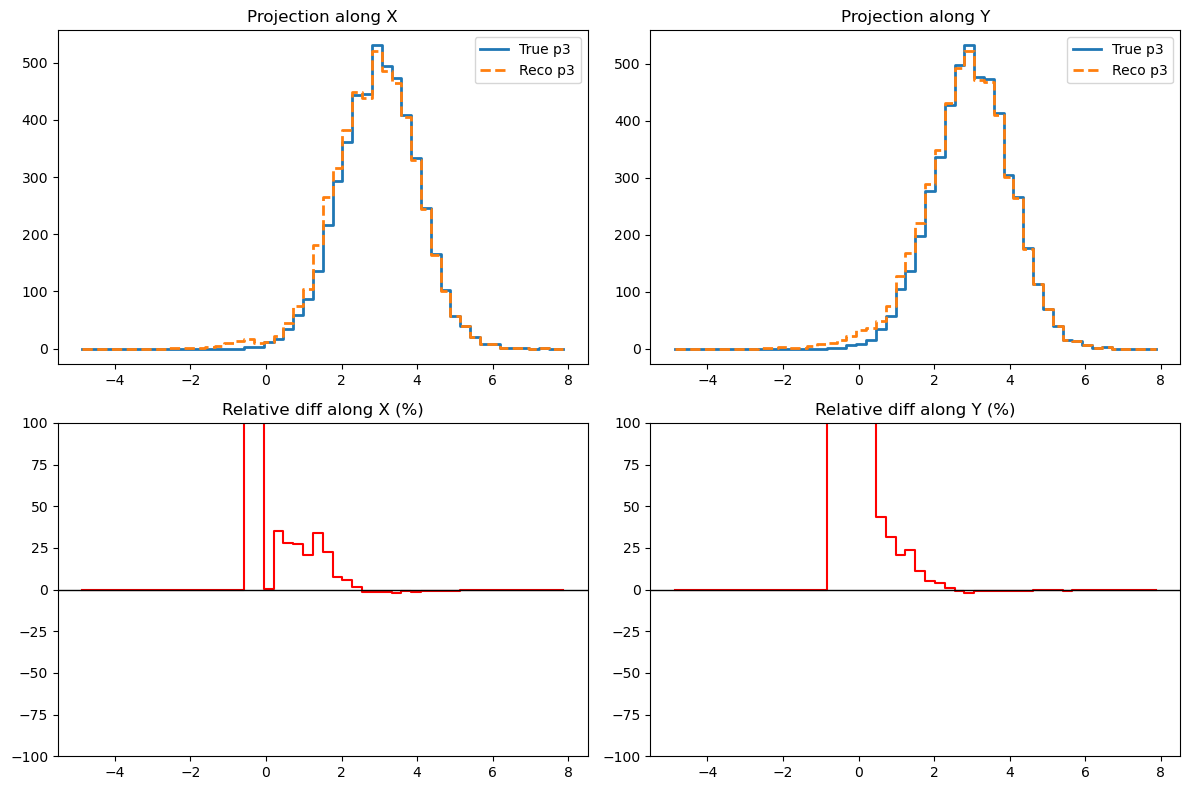

In [11]:

# -----------------------
# 7. 1-D projections (NEW)
# -----------------------
# Project along X
proj_true_x = H_p3_true.sum(axis=1)  # sum over y
proj_reco_x = H_p3_reco.sum(axis=1)
rel_diff_x = np.zeros_like(proj_true_x, dtype=float)
mask_x = proj_true_x != 0
rel_diff_x[mask_x] = (proj_reco_x[mask_x] - proj_true_x[mask_x]) / proj_true_x[mask_x]

# Project along Y
proj_true_y = H_p3_true.sum(axis=0)  # sum over x
proj_reco_y = H_p3_reco.sum(axis=0)
rel_diff_y = np.zeros_like(proj_true_y, dtype=float)
mask_y = proj_true_y != 0
rel_diff_y[mask_y] = (proj_reco_y[mask_y] - proj_true_y[mask_y]) / proj_true_y[mask_y]

# Plot projections with histogram style (step)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# X projections
axes[0,0].step(xcenters, proj_true_x, where='mid', label="True p3", lw=2)
axes[0,0].step(xcenters, proj_reco_x, where='mid', label="Reco p3", lw=2, linestyle='--')
axes[0,0].set_title("Projection along X")
axes[0,0].legend()

axes[1,0].step(xcenters, rel_diff_x*100, where='mid', color='r')  # now in %
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title("Relative diff along X (%)")
axes[1,0].set_ylim(-100, 100)

# Y projections
axes[0,1].step(ycenters, proj_true_y, where='mid', label="True p3", lw=2)
axes[0,1].step(ycenters, proj_reco_y, where='mid', label="Reco p3", lw=2, linestyle='--')
axes[0,1].set_title("Projection along Y")
axes[0,1].legend()

axes[1,1].step(ycenters, rel_diff_y*100, where='mid', color='r')  # now in %
axes[1,1].axhline(0, color='k', lw=1)
axes[1,1].set_title("Relative diff along Y (%)")
axes[1,1].set_ylim(-100, 100)

plt.tight_layout()
plt.show()


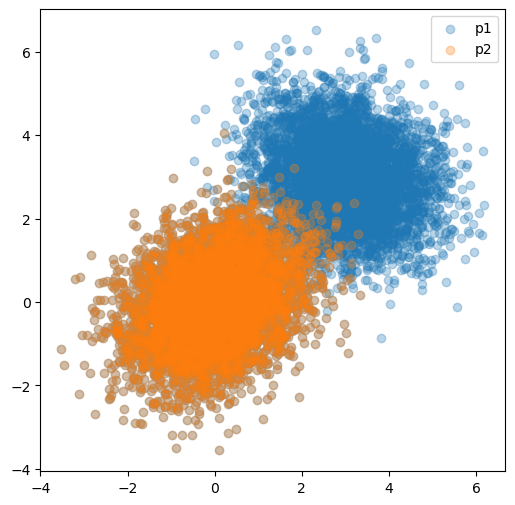

In [ ]:
# Visual check of the original distributions p1 and p2
plt.figure(figsize=(6,6))
plt.scatter(p1_samples[:,0], p1_samples[:,1], alpha=0.3, label='p1')
plt.scatter(p2_samples[:,0], p2_samples[:,1], alpha=0.3, label='p2')
plt.legend()
plt.show()

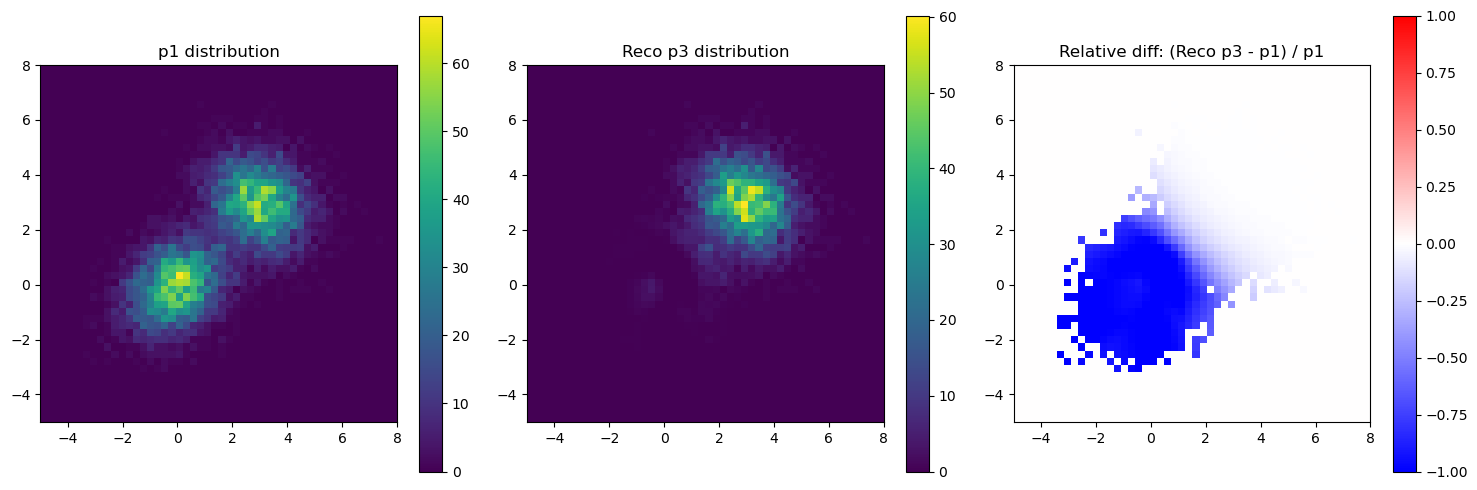

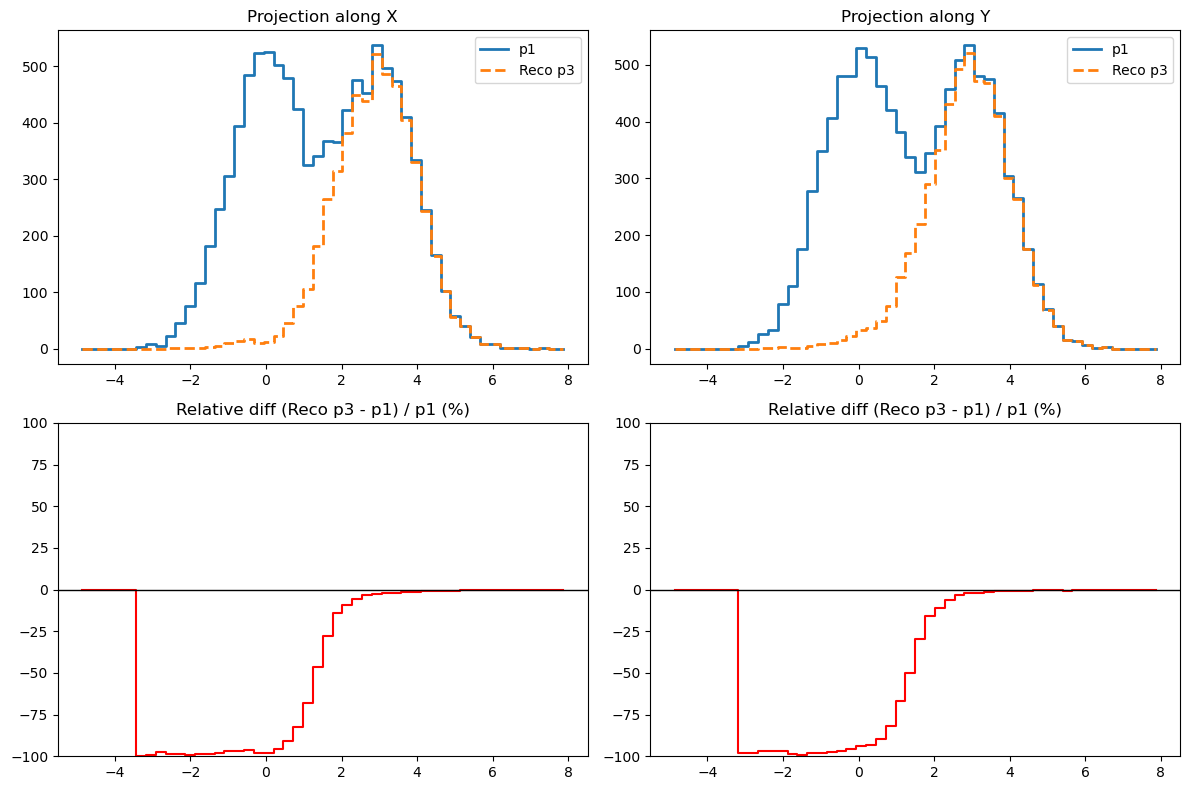

In [12]:
# -----------------------
# 8. Compare shapes: p1 vs Reco p3
# -----------------------
# 2D hist for p1 is H_p1 (already computed)
# Relative difference
mask_nonzero_p1 = H_p1 != 0
rel_diff_p1_vs_p3 = np.zeros_like(H_p1, dtype=float)
rel_diff_p1_vs_p3[mask_nonzero_p1] = (H_p3_reco[mask_nonzero_p1] - H_p1[mask_nonzero_p1]) / H_p1[mask_nonzero_p1]

# Plot 2D comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(H_p1.T, origin='lower', extent=[-5,8,-5,8])
axes[0].set_title("p1 distribution")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(H_p3_reco.T, origin='lower', extent=[-5,8,-5,8])
axes[1].set_title("Reco p3 distribution")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(rel_diff_p1_vs_p3.T, origin='lower', extent=[-5,8,-5,8], cmap='bwr', vmin=-1, vmax=1)
axes[2].set_title("Relative diff: (Reco p3 - p1) / p1")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# -----------------------
# 9. 1D projections: p1 vs Reco p3
# -----------------------
# Project along X
proj_p1_x = H_p1.sum(axis=1)
proj_reco_p3_x = H_p3_reco.sum(axis=1)
rel_diff_x_p1p3 = np.zeros_like(proj_p1_x, dtype=float)
mask_x2 = proj_p1_x != 0
rel_diff_x_p1p3[mask_x2] = (proj_reco_p3_x[mask_x2] - proj_p1_x[mask_x2]) / proj_p1_x[mask_x2]

# Project along Y
proj_p1_y = H_p1.sum(axis=0)
proj_reco_p3_y = H_p3_reco.sum(axis=0)
rel_diff_y_p1p3 = np.zeros_like(proj_p1_y, dtype=float)
mask_y2 = proj_p1_y != 0
rel_diff_y_p1p3[mask_y2] = (proj_reco_p3_y[mask_y2] - proj_p1_y[mask_y2]) / proj_p1_y[mask_y2]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# X projections
axes[0,0].step(xcenters, proj_p1_x, where='mid', label="p1", lw=2)
axes[0,0].step(xcenters, proj_reco_p3_x, where='mid', label="Reco p3", lw=2, linestyle='--')
axes[0,0].set_title("Projection along X")
axes[0,0].legend()

axes[1,0].step(xcenters, rel_diff_x_p1p3*100, where='mid', color='r')
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title("Relative diff (Reco p3 - p1) / p1 (%)")
axes[1,0].set_ylim(-100, 100)

# Y projections
axes[0,1].step(ycenters, proj_p1_y, where='mid', label="p1", lw=2)
axes[0,1].step(ycenters, proj_reco_p3_y, where='mid', label="Reco p3", lw=2, linestyle='--')
axes[0,1].set_title("Projection along Y")
axes[0,1].legend()

axes[1,1].step(ycenters, rel_diff_y_p1p3*100, where='mid', color='r')
axes[1,1].axhline(0, color='k', lw=1)
axes[1,1].set_title("Relative diff (Reco p3 - p1) / p1 (%)")
axes[1,1].set_ylim(-100, 100)

plt.tight_layout()
plt.show()
